# Brouillon - Tests avant modelisation finale

Ce notebook contient les essais intermediaires (nettoyage, encodage, comparaison de modeles) realises avant la version finale de modelisation.

In [3]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

candidate_paths = [Path("../data/bp_summary_classified.csv"), Path("data/bp_summary_classified.csv"), Path("bp_summary_classified.csv")]
data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("bp_summary_classified.csv not found in expected locations")

df = pd.read_csv(data_path)
print("Shape:", df.shape)
df.head()

Shape: (1580, 47)


,source_file,test_begin,age,sex,date_of_birth,all_avg_sys,all_avg_dia,day_avg_sys,day_avg_dia,day_bp_threshold_sys,...,bp_cv_all_dia_pct,bp_cv_day_sys_pct,bp_cv_day_dia_pct,bp_cv_night_sys_pct,bp_cv_night_dia_pct,contents,diagnostics,aasi_sys,readings_count,health_label
0,ID_0001_cleaned.pdf,2024/03/26 14:01:00,73.0,Male,1951/01/18,132.1,63.9,139.4,71.1,135.0,...,21.2,8.5,15.1,6.6,21.1,CHIFFRES > NLE ET DES PICS A 170/90 MMHG . TRA...,PROFIL TENSIONNEL ELEVE SURTOUT EN PERIODE DIU...,0.17,34,not
1,ID_0002_cleaned.pdf,2021/06/14 10:31:00,68.0,Female,1953/11/19,111.6,58.3,115.3,60.7,135.0,...,15.8,10.8,15.9,5.3,10.0,111/58 MMHG . DR BEN MILED MEHDI,PROFIL TENSIONNEL PARFAITMENT NORMAL AUSSI BIE...,0.56,42,healthy
2,ID_0003_cleaned.pdf,2023/03/04 09:30:00,50.0,Male,1973/03/14,126.1,75.8,131.6,82.6,135.0,...,17.3,7.0,9.1,11.3,13.5,NORMAL. A SURVEILLER SOUS MEUSURES DIETETIQUES...,PROFIL TENSIONNEL LIMITE EN PERIODE DIURNE A V...,0.20,24,not
3,ID_0004_cleaned.pdf,2023/03/08 09:01:00,60.0,Male,1963/08/10,132.3,71.5,138.8,75.0,135.0,...,15.5,10.2,13.3,14.5,14.9,NLE ET DES PICS A 170/89 MMHG. PROFIL NOCTURNE...,PROFIL TENSIONNEL ELEVE EN PERIODE DIURNE A VE...,0.48,42,not
4,ID_0005_cleaned.pdf,2021/07/31 11:00:00,38.0,Female,1983/02/01,131.2,82.3,128.8,82.0,135.0,...,16.8,11.7,16.0,11.9,18.5,NOCTURNE FRANCHEMENT ELEVE A VEC UNE MOYENNE A...,PROFIL TENSIONNEL LIMITE EN PERIODE DIURNE A V...,0.32,42,not


In [4]:
def extraire_statut(texte):
    if pd.isna(texte):
        return "Inconnu"
    texte = texte.upper()
    if "MASQUE" in texte or "MASQUEE" in texte:
        return "HTA masquee"
    if "BLOUSE BLANCHE" in texte or "CABINET" in texte:
        return "Effet blouse blanche"
    if "PARFAIT" in texte or "NORMAL" in texte:
        return "Normale"
    if "ELEVE" in texte or "HYPERTENSION" in texte:
        return "HTA vraie"
    if "LIMITE" in texte or "BORDERLINE" in texte:
        return "Limite"
    return "Inconnu"

df["statut_tensionnel"] = df["diagnostics"].apply(extraire_statut)
print(df["statut_tensionnel"].value_counts())

statut_tensionnel
HTA vraie    756
Normale      635
Inconnu      120
Limite        69
Name: count, dtype: int64


In [5]:
cols_to_drop = [
    "source_file",
    "date_of_birth",
    "test_begin",
    "max_sys_datetime",
    "min_sys_datetime",
    "max_dia_datetime",
    "min_dia_datetime",
    "contents",
    "diagnostics",
    "day_bp_load_value_rule",
    "night_bp_load_value_rule",
    "circadian_normal_range",
]

df = df.drop(columns=cols_to_drop, errors="ignore")
df = df[df["readings_count"] > 0].copy()
df = df.dropna(subset=["all_avg_sys"]).copy()

df["age"] = df["age"].fillna(df["age"].median())
df["aasi_sys"] = df["aasi_sys"].fillna(df["aasi_sys"].median())
df["circadian_sys_night_des_pct"] = df["circadian_sys_night_des_pct"].fillna(0)
df["circadian_dia_night_des_pct"] = df["circadian_dia_night_des_pct"].fillna(0)

print("Shape apres nettoyage:", df.shape)
df.isnull().sum()[df.isnull().sum() > 0]

Shape apres nettoyage: (1579, 36)


Series([], dtype: int64)

In [6]:
df["sex"] = LabelEncoder().fit_transform(df["sex"])
df["health_label"] = df["health_label"].map({"healthy": 1, "not": 0})

le = LabelEncoder()
df["statut_tensionnel_encoded"] = le.fit_transform(df["statut_tensionnel"])

df_ml = df[df["statut_tensionnel"] != "Inconnu"].copy()
X = df_ml.drop(columns=["health_label", "statut_tensionnel", "statut_tensionnel_encoded"])
y = df_ml["statut_tensionnel_encoded"]

print("Classes:", dict(zip(le.classes_, le.transform(le.classes_))))
print("Shape pour ML:", X.shape, y.shape)

Classes: {'HTA vraie': np.int64(0), 'Inconnu': np.int64(1), 'Limite': np.int64(2), 'Normale': np.int64(3)}
Shape pour ML: (1460, 34) (1460,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (1168, 34) | Test: (292, 34)


In [8]:
le2 = LabelEncoder()
y_train_xgb = le2.fit_transform(y_train)
y_test_xgb = le2.transform(y_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel="rbf", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="mlogloss", random_state=42),
}

results = []

for name, model in models.items():
    if name == "XGBoost":
        model.fit(X_train, y_train_xgb)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test_xgb, y_pred)
        f1 = f1_score(y_test_xgb, y_pred, average="weighted")
    elif name in ["Logistic Regression", "SVM", "KNN"]:
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="weighted")
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="weighted")

    results.append({"Modele": name, "Accuracy": round(acc * 100, 2), "F1-Score": round(f1 * 100, 2)})
    print(f"{name} -> Accuracy: {acc * 100:.2f}% | F1: {f1 * 100:.2f}%")

Logistic Regression -> Accuracy: 89.38% | F1: 87.56%
Random Forest -> Accuracy: 90.41% | F1: 88.39%
SVM -> Accuracy: 89.73% | F1: 87.56%
KNN -> Accuracy: 88.36% | F1: 86.20%
Decision Tree -> Accuracy: 89.38% | F1: 89.40%
Gradient Boosting -> Accuracy: 90.07% | F1: 88.86%
XGBoost -> Accuracy: 89.38% | F1: 88.34%


In [9]:
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_df

,Modele,Accuracy,F1-Score
0,Random Forest,90.41,88.39
1,Gradient Boosting,90.07,88.86
2,SVM,89.73,87.56
3,Logistic Regression,89.38,87.56
4,Decision Tree,89.38,89.40
5,XGBoost,89.38,88.34
6,KNN,88.36,86.20


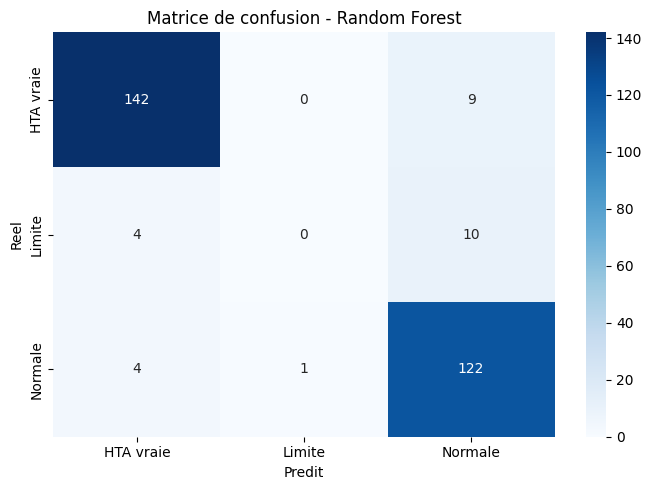

In [10]:
best_name = results_df.iloc[0]["Modele"]
best_model = models[best_name]

if best_name in ["Logistic Regression", "SVM", "KNN"]:
    y_pred_best = best_model.predict(X_test_sc)
else:
    y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
class_names = le.classes_[[int(c) for c in sorted(y.unique())]]

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title(f"Matrice de confusion - {best_name}")
plt.ylabel("Reel")
plt.xlabel("Predit")
plt.tight_layout()
plt.show()